In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
import matplotlib.dates as mdates

# Tukaj vpiši stevilo vseh zvezd katerim spremljamo fotometrijo
stevilo_vseh_zvezd = 2

In [107]:
# 1. Naložimo podatke
# Uporabimo regularni izraz '\s+' za ločevanje stolpcev (več presledkov)
stolpci = ['IMAGE', 'XCENTER', 'YCENTER', 'MAG', 'MERR', 'IFILTER', 'OTIME', 'ID']
pot_do_podatkov = 'Obdelani_podatki/rezultati_fotometrija.txt'

df = pd.read_csv(pot_do_podatkov, sep=r'\s+', names=stolpci)

# 2. Očistimo 'INDEF' vrednosti in pretvorimo v številke
# IRAF zapiše INDEF, kadar zvezde ne more izmeriti. To zamenjamo z NaN in odstranimo.
df['MAG'] = pd.to_numeric(df['MAG'], errors='coerce')
df['MERR'] = pd.to_numeric(df['MERR'], errors='coerce')
df['OTIME'] = pd.to_numeric(df['OTIME'], errors='coerce')
df['XCENTER'] = pd.to_numeric(df['XCENTER'], errors='coerce')
df['YCENTER'] = pd.to_numeric(df['YCENTER'], errors='coerce')

df = df.dropna(subset=['MAG', 'OTIME'])

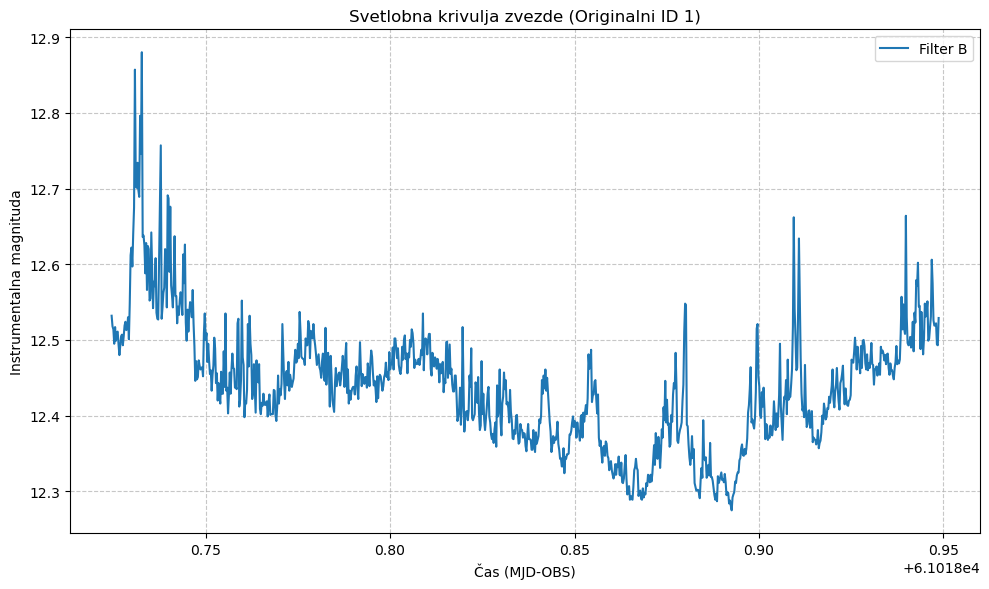

Število uspešnih meritev za to zvezdo: 960


In [108]:

# Določitev pravega ID-ja pred kakršnimkoli brisanjem!
# Uporabimo matematični trik, o katerem sva prej govorila
df['PRAVI_ID'] = (df['ID'] - 1) % stevilo_vseh_zvezd + 1
# Sedaj lahko pobrišemo INDEF meritve
df = df.dropna(subset=['MAG', 'OTIME'])
# 3. Izoliramo in izrišemo podaktke
# TUKAJ VPIŠI ZAPOREDNO ŠTEVILKO MIRE IZ TVOJE .coo DATOTEKE (npr. 1)
mira_id = 1 
mira_df = df[df['PRAVI_ID'] == mira_id].copy()
mira_df = mira_df.sort_values(by='OTIME')
mira_df = mira_df[:-59]

# 4. Izris svetlobne krivulje
plt.figure(figsize=(10, 6))
for filter_ime, podatki_filtra in mira_df.groupby('IFILTER'):
#    plt.errorbar(podatki_filtra['OTIME'], podatki_filtra['MAG'], 
#                 yerr=podatki_filtra['MERR'], fmt='o', label=f'Filter {filter_ime}', 
#                 markersize=5, capsize=3, linestyle='-')
    #Plot brez errorbarja
    plt.plot(podatki_filtra['OTIME'], podatki_filtra['MAG'], label=f'Filter {filter_ime}', 
                 markersize=5, linestyle='-')
#plt.gca().invert_yaxis() # V astronomiji gredo magnitude navzdol!
plt.xlabel('Čas (MJD-OBS)')
plt.ylabel('Instrumentalna magnituda')
plt.title(f'Svetlobna krivulja zvezde (Originalni ID {mira_id})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Lahko izpišeš in paziš tudi druge zvezde za primerjavo (npr referenco)
print(f"Število uspešnih meritev za to zvezdo: {len(mira_df)}")



In [109]:
star_id = 2 #

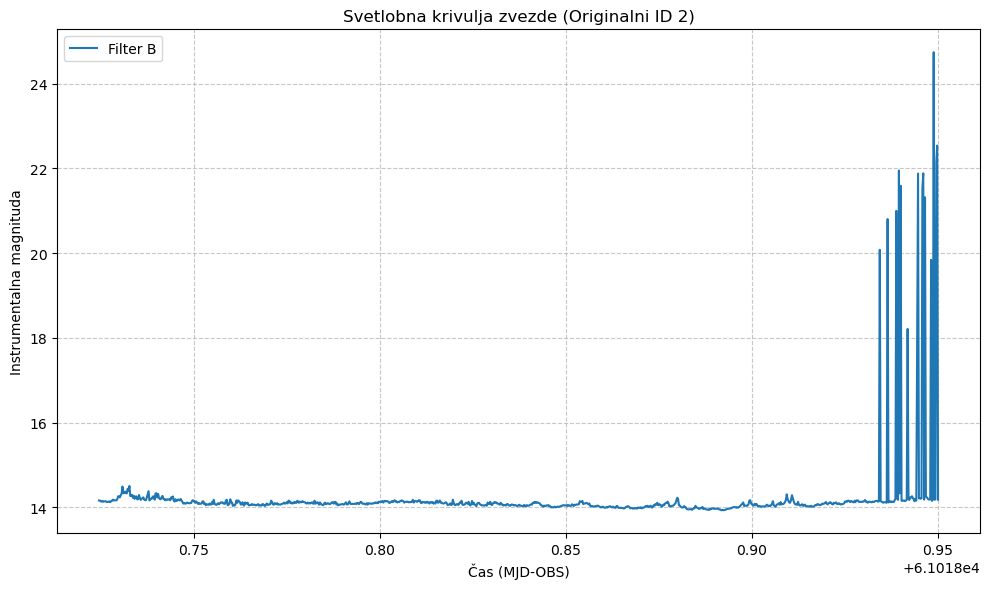

Število uspešnih meritev za to zvezdo: 960


In [110]:
# Določitev pravega ID-ja pred kakršnimkoli brisanjem!
# Uporabimo matematični trik, o katerem sva prej govorila
df['PRAVI_ID'] = (df['ID'] - 1) % stevilo_vseh_zvezd + 1
# Sedaj lahko pobrišemo INDEF meritve
df = df.dropna(subset=['MAG', 'OTIME'])
# 3. Izoliramo in izrišemo podaktke
# TUKAJ VPIŠI ZAPOREDNO ŠTEVILKO MIRE IZ TVOJE .coo DATOTEKE (npr. 1)

zvezda_df = df[df['PRAVI_ID'] == star_id].copy()
zvezda_df = zvezda_df.sort_values(by='OTIME')
zvezda_df = zvezda_df[:-59]

# 4. Izris svetlobne krivulje
plt.figure(figsize=(10, 6))
for filter_ime, podatki_filtra in zvezda_df.groupby('IFILTER'):
#    plt.errorbar(podatki_filtra['OTIME'], podatki_filtra['MAG'], 
#                 yerr=podatki_filtra['MERR'], fmt='o', label=f'Filter {filter_ime}', 
#                 markersize=5, capsize=3, linestyle='-')
    #Plot brez errorbarja
    plt.plot(podatki_filtra['OTIME'], podatki_filtra['MAG'], label=f'Filter {filter_ime}', 
                 markersize=5, linestyle='-')
#plt.gca().invert_yaxis() # V astronomiji gredo magnitude navzdol!
plt.xlabel('Čas (MJD-OBS)')
plt.ylabel('Instrumentalna magnituda')
plt.title(f'Svetlobna krivulja zvezde (Originalni ID {star_id})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Lahko izpišeš in paziš tudi druge zvezde za primerjavo (npr referenco)
print(f"Število uspešnih meritev za to zvezdo: {len(zvezda_df)}")

In [111]:
# 1. Naložimo podatke
# Uporabimo regularni izraz '\s+' za ločevanje stolpcev (več presledkov)
stolpci = ['IMAGE', 'XCENTER', 'YCENTER', 'MAG', 'MERR', 'IFILTER', 'OTIME', 'ID']
pot_do_podatkov = 'Obdelani_podatki/rezultati_fotometrija.txt'

df = pd.read_csv(pot_do_podatkov, sep=r'\s+', names=stolpci)

# 2. Očistimo 'INDEF' vrednosti in pretvorimo v številke
# IRAF zapiše INDEF, kadar zvezde ne more izmeriti. To zamenjamo z NaN in odstranimo.
df['MAG'] = pd.to_numeric(df['MAG'], errors='coerce')
df['MERR'] = pd.to_numeric(df['MERR'], errors='coerce')
df['OTIME'] = pd.to_numeric(df['OTIME'], errors='coerce')
df['XCENTER'] = pd.to_numeric(df['XCENTER'], errors='coerce')
df['YCENTER'] = pd.to_numeric(df['YCENTER'], errors='coerce')

df = df.dropna(subset=['MAG', 'OTIME'])


# Določitev pravega ID-ja pred kakršnimkoli brisanjem!
# Uporabimo matematični trik, o katerem sva prej govorila
df['PRAVI_ID'] = (df['ID'] - 1) % stevilo_vseh_zvezd + 1
# Sedaj lahko pobrišemo INDEF meritve
df = df.dropna(subset=['MAG', 'OTIME'])


In [112]:
# TUKAJ VPIŠI PRAVE ID-JE:
mira_id = 1          # ID Mire v big anulus podatkih je 2

ref_zvezda_id = 2

<>:71: SyntaxWarning: invalid escape sequence '\D'
<>:71: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_4236/243390178.py:71: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('Diferencialna magnituda ($\Delta m$)')


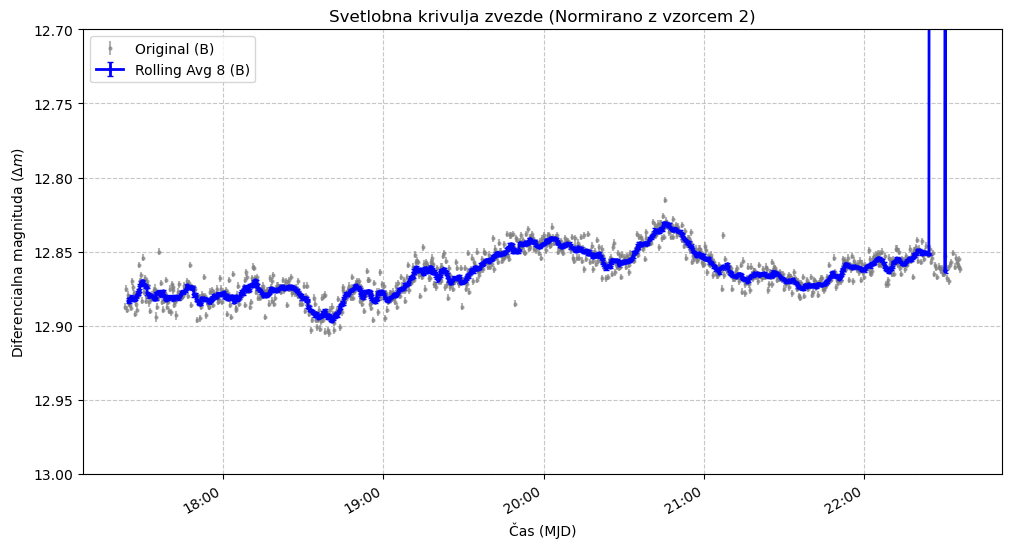

In [ ]:


# 1. Izluščimo samo našo referenčno zvezdo in obdržimo LE nujne stolpce
ref_podatki = df[df['PRAVI_ID'] == ref_zvezda_id][['IMAGE', 'MAG', 'MERR']]

# 2. Preimenujemo no njena stolpca, da ju kasneje ločimo od Mire
ref_podatki = ref_podatki.rename(columns={'MAG': 'REF_MAG', 'MERR': 'REF_MERR'})

# 3. Združimo to referenčno "bazo" nazaj z glavno tabelo (povežemo preko pripadajoče slike)
df = pd.merge(df, ref_podatki, on='IMAGE')

# 4. Izračunamo razliko (diferencialno magnitudo) + dodamo tvojo konstanto 14.52
df['DIFF_MAG'] = df['MAG'] - df['REF_MAG'] + 14.52

# 5. Nova napaka je koren vsote kvadratov obeh posameznih napak
df['DIFF_MERR'] = np.sqrt(df['MERR']**2 + df['REF_MERR']**2)



# --------- ZDAJ LAHKO IZLUŠČIMO SAMO MIRO ---------
mira_df = df[df['PRAVI_ID'] == mira_id].copy()
# Pretvorba MJD v prave ure (datetime format)
casi = Time(mira_df['OTIME'].values, format='mjd')

# Lahko dodaš še 1 uro (ali 2 poleti) za slovenski lokalni čas, če želiš:
# from datetime import timedelta
# mira_df['URE'] = casi.datetime + timedelta(hours=1)

mira_df['URE'] = casi.datetime

# Sortiramo da bo krivulja pravilna
mira_df = mira_df.sort_values(by='URE')

# Tu odščipni morebitne divje podatke (recimo odreži prvih 5 in zadnjih 50 slik)
mira_df = mira_df[:-80]


# Naredimo drseče povprečje čez 5 sosednjih meritev. 
# "center=True" pomeni, da bo povprečje postavljeno na sredinsko točko (tretjo od petih)
velikost_okna = 8
mira_df['ROLLING_MAG'] = mira_df['DIFF_MAG'].rolling(window=velikost_okna, center=True).mean()

# Opcijsko: pri povprečenju N meritev se statistična napaka zmanjša za koren iz N!
mira_df['ROLLING_MERR'] = mira_df['DIFF_MERR'].rolling(window=velikost_okna, center=True).mean() / np.sqrt(velikost_okna)


# --- IZRIS ---
plt.figure(figsize=(10, 6))

for filter_ime, podatki_filtra in mira_df.groupby('IFILTER'):
    # Pri izrisu zdaj za Y podamo novo normirano magnitudo (DIFF_MAG)
#       plt.errorbar(podatki_filtra['OTIME'], podatki_filtra['DIFF_MAG'], 
#                    yerr=podatki_filtra['DIFF_MERR'], fmt='.', label=f'Filter {filter_ime}', 
#                    markersize=3, capsize=3)
    #Navaden plot
    #plt.scatter(podatki_filtra['URE'], podatki_filtra['DIFF_MAG'], label=f'Filter {filter_ime}')

    # 1. Bledo (alpha=0.2) prerišemo vse originalne surove meritve
    plt.errorbar(podatki_filtra['URE'], podatki_filtra['DIFF_MAG'], 
                 yerr=podatki_filtra['DIFF_MERR'], fmt='o', color='gray', alpha=0.6, 
                 markersize=2, label=f'Original ({filter_ime})')
                 
    # 2. Močno (brez alpha) pa izrišemo naše zglajeno drseče povprečje
    plt.errorbar(podatki_filtra['URE'], podatki_filtra['ROLLING_MAG'], 
                 yerr=podatki_filtra['ROLLING_MERR'], fmt='-o', color='blue', 
                 linewidth=2, markersize=2, capsize=2, label=f'Rolling Avg {velikost_okna} ({filter_ime})')


# Vrne os nazaj - da gre navzgor za bolj svetlo (čeprav se pri diferencialni lahko orientiraš tudi drugače)
#plt.gca().invert_yaxis() 

plt.xlabel('Čas (MJD)')
plt.ylabel('Diferencialna magnituda ($\Delta m$)')
plt.title(f'Svetlobna krivulja zvezde)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.ylim(13, 12.7)
# TO DODAJ PRED plt.show():
# Povemo grafu, naj X os formatira samo kot yyyy-mm-dd HH:MM:SS
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gcf().autofmt_xdate() # Ta ukaz lepo nagne tekst ur pod kotom, da se ne prekrivajo!
plt.show()
